In [356]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import seaborn as sns

# The goal of this notebook is to find a way to compute the velocity attenuation ratio of a PIV dataset. Several strategies will be attempted
# and compared. Specifically, I want the ration of flow speed local to polyps over the free stream flow speed far from the coral. I am also
# not sure whether I am supposed to use the magnitude of the velocity (speed) or just the x-component (u). As such, there will be variations
# for that as well

# I need to be able to both characterize around the polyps (still unclear whether one or all) and then across the whole image. I think
# starting with the latter will be a bit easier.

#Some possible distinctions:
#1. Single frame vs composite over many frames
#2. Single polyp vs many polyps
#3. U component vs speed

#Credit to Alison Weber for helping debug the rectangle on the heatmaps!

In [314]:
def break_down_data(filename):
    '''
    Reads the csv file and derives some useful numbers. Used to save space when plotting heatmaps.

    Parameters:
    String filename: path to the file you would like to analyze

    Returns, in order:
    DataFrame data = the Pandas DataFrame with all data
    String xcol, ycol, ucol, vcol = the names of the columns with the x coordinate, y coordinate, u-component of velocity, and v-component of 
    velocity, respectively. Allows generalizability with calibrated and noncalibrated data.
    int col_len = the number of data points
    vec_dist = the distance between each vector data point
    int xmin, xmax = maximum and minimum x values in the ORIGINAL data
    Numpy Array xrange = A numpy arange array of all x data. Does not correspond to image coordinates or the max/min
    int ymin, ymax = maximum and minimum y values in the ORIGINAL data
    Numpy Array yrange = A numpy arange array of all y data. Does not correspond to image coordinates or the max/min
    Numpy 2D Array xy = An array that creates a grid with exactly as many entries as there will be data points
    '''

    data = pd.read_csv(filename)

    #Get column names for x, y, and u. This makes it generalizable between calibrated and uncalibrated data
    xcol = data.columns[0]
    ycol = data.columns[1]
    ucol = data.columns[2]
    vcol = data.columns[3]
    #define the amount of data points (assuming same number of data in each col)
    col_len = len(data[xcol])

    #finds distance between vectors (will be useful later)
    for i in np.arange(col_len):
        vec_dist = data[xcol][i]-data[xcol][0]
        if vec_dist != 0:
            break

    #Some useful size variables
    xmin = data[xcol].min()
    xmax = data[xcol].max()
    xrange = np.unique(data[xcol])
    ymin = data[ycol].min()
    ymax = data[ycol].max()
    yrange = np.unique(data[ycol])
    #Initialize an array 
    xy = np.empty((len(yrange), len(xrange)))

    return data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, xy

In [315]:
def draw_heatmap(array, title, diverging = True, normalized = False):
    '''
    Graphs a given 2D array with a heatmap centered at 0, using a dark, diverging colormap that allows masks and NaNs to be seen.
    X and Y labels are turned off and assumed to be relative.

    Parameters:
    2D Array or Arraylike array: a NumPy array or Pandas DataFrame or whatever with the data you want plotted
    String title: Describes what's being plotted
    ''' 
    
    #Graphs the data using a seaborn heatmap
    if diverging:
        heatmap = sns.heatmap(array, center = 0, cmap = "berlin", xticklabels = False, yticklabels = False)
    elif normalized:
        heatmap = sns.heatmap(array, vmin = 0, vmax = 1, cmap = "viridis", xticklabels = False, yticklabels = False)
    #heatmap.xaxis.tick_top()
    plt.xlabel("x (relative)")
    plt.ylabel("y (relative)")
    plt.title(title)
    plt.tight_layout(pad=2.0)

In [316]:
def testMap_u(filename):
    '''
    Returns a heatmap of horizontal speed magnitude, u, and masked out regions are clearly distinguishable.

    Parameters:
    str filename: name of the file
    '''

    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, xy = break_down_data(filename)
    
    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        #u component at that position. THIS IS THE PLACE TO EDIT FOR DIFFERENT VALUES!!
        u_xy = data[ucol][i]
        xy[ypos][xpos] = u_xy

    #I know this is all convoluted I just don't know how to do it better

    draw_heatmap(xy, "u-component of velocity")

In [317]:
def u_comp_vel_attenuation():
    '''
    Not yet implemented. Will find velocity attenuation for the u-component and return a list of the resulting values in the same order as
    the original dataframe.

    Intent is to use it to simplify the velocity_attenuation_heatmap and ultimately be able to return velocity attenuation values for further stuff.

    Another function for magnitude will be done as well.
    '''

In [399]:
def velocity_attenuation_heatmap(filename, x1free, y1free, x2free, y2free):
    '''
    Returns two heatmaps of velocity attenuation compared to a defined free-stream area for an individual frame.
    One will compare strictly the u-component. One will compare the magnitude of the velocity.

    Also draws a rectangle of the defined free stream area over the plot.

    Parameters:
    String filename: path of file for analysis

    The following parameters are meant to give a rectangle of area considered to have "free stream" behavior, far away from the coral sample.
    These values are INCLUSIVE
    int x1free: Left bound
    int y1free: Top bound
    int x2free: Right bound
    int y2free: Bottom bound
    These assume x increasing to the right and y increasing toward the bottom
    '''

    #Unloads data
    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, pointarray_u = break_down_data(filename)

    #Pseudocode:
    #Make a copy of pointarray_u for magnitude
    pointarray_mag = pointarray_u
    
    #Average u and mag over the rectangle using a for loop to get the free stream velocity

    #u component
    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        if (data[xcol][i]>=x1free and data[xcol][i]<=x2free and data[ycol][i]>=y1free and data[ycol][i]<=y2free):
            counter+=1
            cumsum+=data[ucol][i]
    mean_u = cumsum/counter

    #velocity magnitude
    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        if (data[xcol][i]>=x1free and data[xcol][i]<=x2free and data[ycol][i]>=y1free and data[ycol][i]<=y2free):
            counter+=1
            temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
            cumsum+= math.sqrt(temp) #(x^2+y^2)^(1/2)
    mean_mag = cumsum/counter
    
    #For the whole data set, find the velocity attenuation as the velocity at that point over the free stream velocity
    #Add the results to the original DataFrame

    #u component
    u_attenuation = np.zeros(col_len)
    for i in np.arange(col_len):
        u_attenuation[i] = data[ucol][i]/mean_u
        
    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        pointarray_u[ypos][xpos] = u_attenuation[i]

    #vel magnitude
    mag_attenuation = np.zeros(col_len)
    velmag = np.zeros(col_len)
    for i in np.arange(col_len):
        temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
        temp = math.sqrt(temp) #(x^2+y^2)^(1/2)
        velmag[i] = temp
        mag_attenuation[i] = temp/mean_mag

    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        pointarray_mag[ypos][xpos] = mag_attenuation[i]
    
    #Graph each using the draw_heatmap() function

    #rect = mpatches.Rectangle((left, bottom), width, height, fill=False, edgecolor="purple", linewidth=2)
    rect = mpatches.Rectangle((x1free//vec_dist, y1free//vec_dist), (x2free//vec_dist-x1free//vec_dist), (y2free//vec_dist-y1free//vec_dist), fill=False, edgecolor="red", linewidth=2)
    ax = plt.gca()
    rect.set_zorder(10000)
    
    plt.figure(figsize=(5,8))
    plt.subplot(211)
    draw_heatmap(pointarray_u, "Velocity Attenuation Ratio for U Component", normalized = True, diverging = False)
    ax.add_patch(rect)
    rect.set_zorder(10000)
    plt.subplot(212)
    draw_heatmap(pointarray_mag, "Velocity Attenuation Ratio for Total Velocity Magnitude", normalized = True, diverging = False)
    ax.add_patch(rect)
    rect.set_zorder(10000)
    plt.show()
    

In [400]:
testfile = "C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation Python Code/filtered_t5_2pass_small/filtered_t5_2pass_small_0090.txt"
testfile1 = "C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation Python Code/filtered_t5_2pass_small/filtered_t5_2pass_small_0009.txt"
itsdataingtime = pd.read_csv(testfile)
print(itsdataingtime[itsdataingtime.columns[0]].max(), itsdataingtime[itsdataingtime.columns[0]].min(), itsdataingtime[itsdataingtime.columns[1]].max(), itsdataingtime[itsdataingtime.columns[1]].min())

926 270 736 128


In [408]:
def velocity_attenuation_heatmap_aiw(filename, x1free, y1free, x2free, y2free):
    '''
    Returns two heatmaps of velocity attenuation compared to a defined free-stream area for an individual frame.
    One will compare strictly the u-component. One will compare the magnitude of the velocity.

    Also draws a rectangle of the defined free stream area over the plot.

    Parameters:
    String filename: path of file for analysis

    The following parameters are meant to give a rectangle of area considered to have "free stream" behavior, far away from the coral sample.
    These values are INCLUSIVE
    int x1free: Left bound
    int y1free: Top bound
    int x2free: Right bound
    int y2free: Bottom bound
    These assume x increasing to the right and y increasing toward the bottom
    '''

    #Unloads data
    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, pointarray_u = break_down_data(filename)

    #Pseudocode:
    #Make a copy of pointarray_u for magnitude
    pointarray_mag = pointarray_u
    
    #Average u and mag over the rectangle using a for loop to get the free stream velocity

    #u component
    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        if (data[xcol][i]>=x1free and data[xcol][i]<=x2free and data[ycol][i]>=y1free and data[ycol][i]<=y2free):
            counter+=1
            cumsum+=data[ucol][i]
    mean_u = cumsum/counter

    #velocity magnitude
    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        if (data[xcol][i]>=x1free and data[xcol][i]<=x2free and data[ycol][i]>=y1free and data[ycol][i]<=y2free):
            counter+=1
            temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
            cumsum+= math.sqrt(temp) #(x^2+y^2)^(1/2)
    mean_mag = cumsum/counter
    
    #For the whole data set, find the velocity attenuation as the velocity at that point over the free stream velocity
    #Add the results to the original DataFrame

    #u component
    u_attenuation = np.zeros(col_len)
    for i in np.arange(col_len):
        u_attenuation[i] = data[ucol][i]/mean_u
        
    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        pointarray_u[ypos][xpos] = u_attenuation[i]

    #vel magnitude
    mag_attenuation = np.zeros(col_len)
    velmag = np.zeros(col_len)
    for i in np.arange(col_len):
        temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
        temp = math.sqrt(temp) #(x^2+y^2)^(1/2)
        velmag[i] = temp
        mag_attenuation[i] = temp/mean_mag

    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        pointarray_mag[ypos][xpos] = mag_attenuation[i]
    
    #Graph each using the draw_heatmap() function

    #rect = mpatches.Rectangle((left, bottom), width, height, fill=False, edgecolor="purple", linewidth=2)
    
    fig, axes = plt.subplots(1, 2, figsize=(11,5), sharey=True)
    
    plt.sca(axes[0])
    draw_heatmap(pointarray_u, "Velocity Attenuation Ratio for U Component", normalized = True, diverging = False)
    rect = mpatches.Rectangle((x1free//vec_dist, y1free//vec_dist), (x2free//vec_dist-x1free//vec_dist), (y2free//vec_dist-y1free//vec_dist), fill=False, edgecolor="red", linewidth=2)
    axes[0].add_patch(rect)
    rect.set_zorder(10000)

    plt.sca(axes[1])
    draw_heatmap(pointarray_mag, "Velocity Attenuation Ratio for Total Velocity Magnitude", normalized = True, diverging = False)
    rect2 = mpatches.Rectangle((x1free//vec_dist, y1free//vec_dist), (x2free//vec_dist-x1free//vec_dist), (y2free//vec_dist-y1free//vec_dist), fill=False, edgecolor="red", linewidth=2)
    axes[1].add_patch(rect2)
    rect2.set_zorder(10000)
    
    plt.show()
    

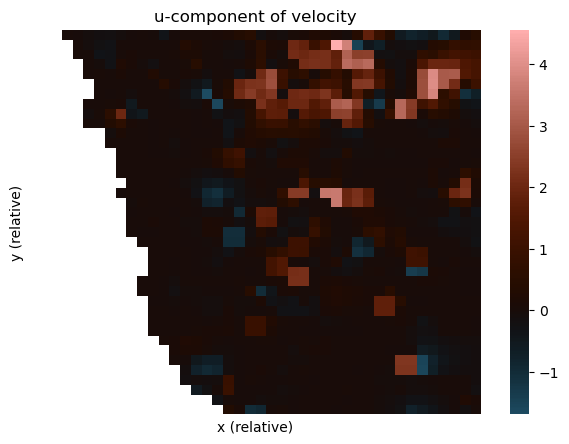

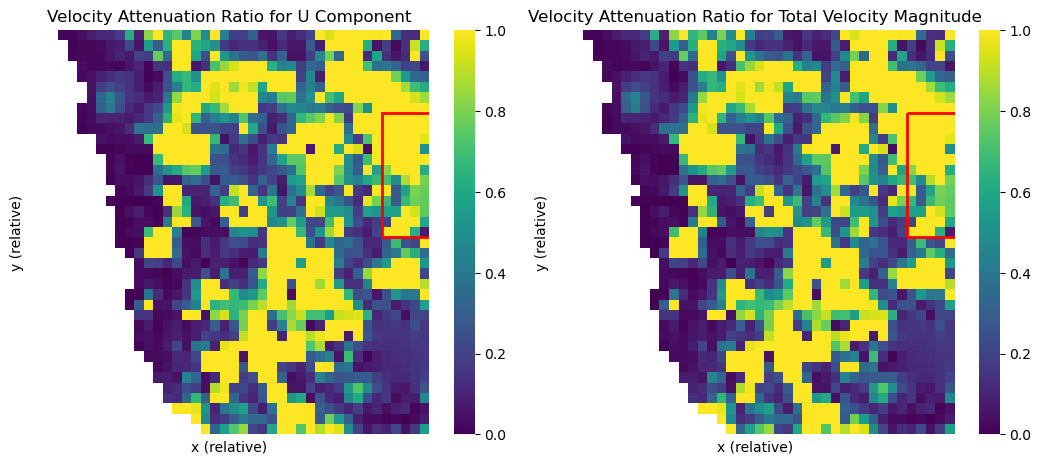

In [409]:
testMap_u(testfile)
velocity_attenuation_heatmap_aiw(testfile1, 600, 128, 926, 328)

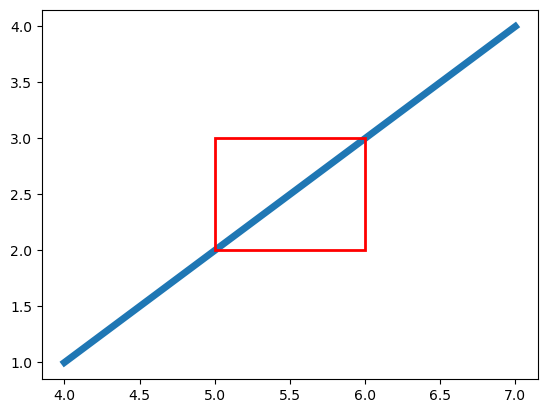

In [380]:
#rect test
x = [4, 5, 6, 7]
y = [1, 2, 3, 4]
rect = mpatches.Rectangle((5, 2), (1), (1), fill=False, edgecolor="red", linewidth=2)
ax = plt.gca()
plt.plot(x, y, linewidth = 5)
ax.add_patch(rect)
rect.set_zorder(2)
plt.show()